# Assignment 3: Exploring Unsupervised Learning with the k-Means Algorithm

## Group Members
#Neeru Neeru
#Rabaya Khatun Keya
#Nerov Kha

## Dataset Description
The **Wine Quality (Red) dataset** contains **1599 red wine samples** with **11 chemical features** (e.g., acidity, alcohol, sugar, sulphates) that influence wine characteristics.  

The dataset also includes a **quality score**, but it is **not used** for clustering.  

This dataset is suitable for **k-means clustering** because the features provide measurable differences between wines, allowing natural groupings to form.  

## Real-World Uses of k-Means

1. **Customer Segmentation:** Businesses use k-means to group customers based on purchasing behavior, demographic patterns or spending habits. This helps in targeted marketing and personalized recommendations.

2. **Image Compression:** k-means can reduce the number of colors in an image by clustering similar pixel values. This produces smaller image files while maintaining visual quality.


## Load Libraries
These libraries support data handling, visualization, preprocessing and clustering.

In [ ]:
# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# For warnings
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")


## Load Dataset
The dataset is read from a CSV file. The first few rows help confirm successful loading.

In [ ]:
from google.colab import files

# Upload the file
uploaded = files.upload()  # This will open a file chooser

# Now the file is in the current working directory, you can read it
data = pd.read_csv("WineQT.csv")

# Check first few rows
print(data.head())
print("Dataset shape:", data.shape)
print(data.info())


Saving WineQT.csv to WineQT.csv
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1 

## Data Cleaning
This section checks for missing values and removes duplicates. It ensures the dataset is clean before applying clustering.

In [ ]:
# Check for missing values
print("Missing values per column:\n", data.isnull().sum())

# Check for duplicates
duplicates = data.duplicated().sum()
print("Number of duplicate rows:", duplicates)
# Remove duplicates if any
data = data.drop_duplicates()

# Optional: Remove outliers using z-score (threshold 3)
from scipy.stats import zscore
z_scores = np.abs(zscore(data.drop('quality', axis=1)))
data = data[(z_scores < 3).all(axis=1)]

print("Dataset shape after cleaning:", data.shape)


Missing values per column:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64
Number of duplicate rows: 0
Dataset shape after cleaning: (1046, 13)


## Correlation Matrix
The correlation matrix helps identify relationships between features. Strong correlations may influence clustering because some features will dominate.

The heatmap highlights how strongly each pair of variables is related.

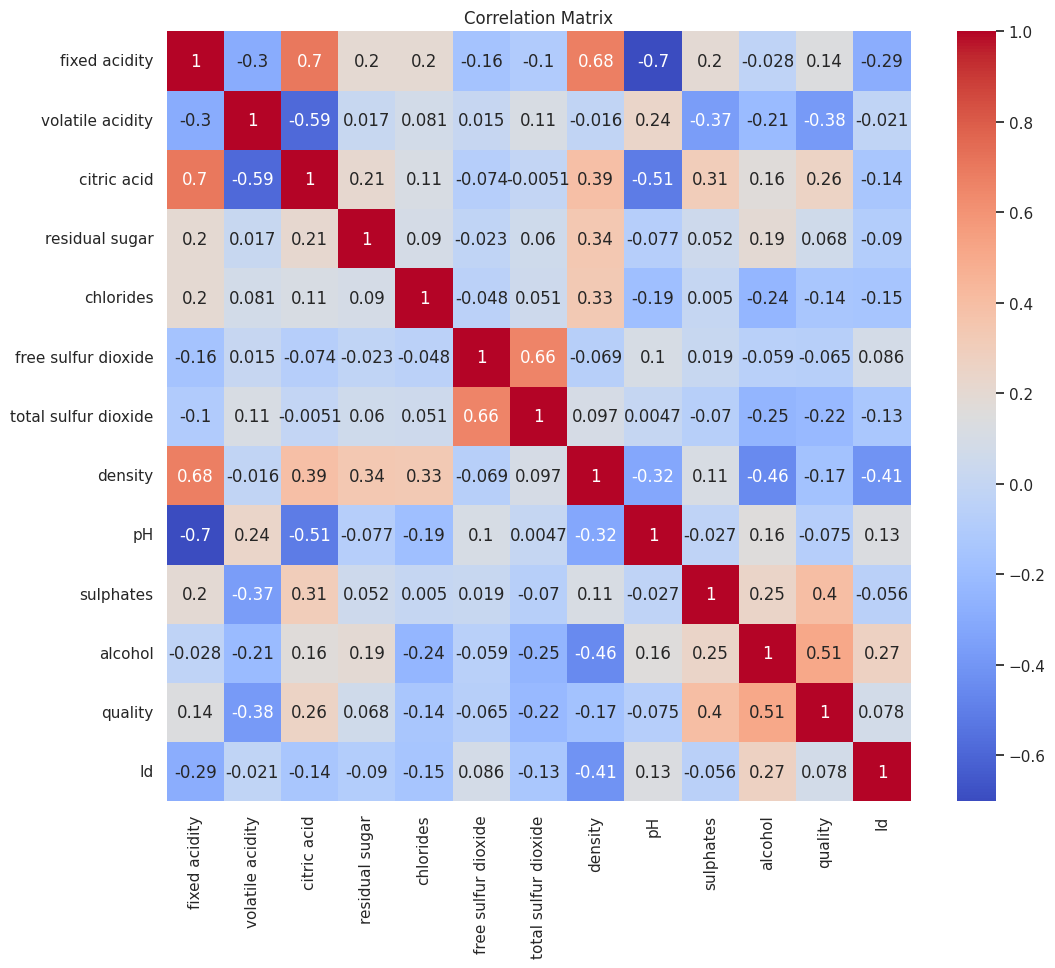

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Correlation Matrix Analysis

The correlation matrix shows the strength and direction of relationships between all pairs of features in the dataset.  

- Values range from **-1 to 1**:  
  - **1** → strong positive correlation (as one feature increases, the other also increases)  
  - **-1** → strong negative correlation (as one feature increases, the other decreases)  
  - **0** → no linear relationship  

- Observations from the heatmap:
  - Features with high positive correlation (e.g., `total sulfur dioxide` and `free sulfur dioxide`) may influence clustering more strongly if not scaled.
  - Features with low or negative correlation provide unique information that helps separate clusters.
  - This analysis helps understand which features are related and may guide feature selection or interpretation of clusters.


## Preprocessing
Features are scaled with StandardScaler. This step is essential for k-means because the algorithm is sensitive to differences in scale.

In [ ]:
X = data.drop('quality', axis=1)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Preprocessing Explanation

Feature scaling is necessary before applying k-means because the algorithm is sensitive to differences in feature ranges. Without scaling, variables with large numeric values would dominate the distance calculations and distort the clustering results. StandardScaler was used to ensure all features contribute equally by transforming them to have zero mean and unit variance. This helps k-means form clusters based on the true structure of the dataset rather than the scale of the variables.


## Parameter Tuning with the Elbow Method
The elbow method evaluates different values of k. The sum of squared errors (SSE) becomes stable at a certain point. That point is considered a good choice for the number of clusters.

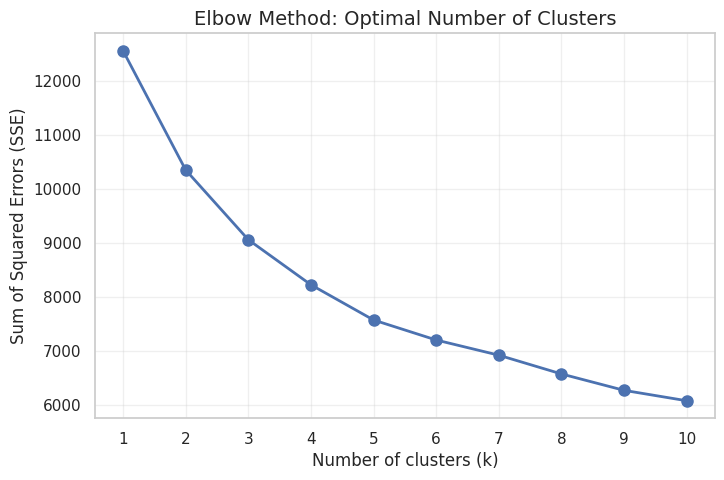

In [ ]:
sse = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

# Plot Elbow
plt.figure(figsize=(8,5))
plt.plot(k_range, sse, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of clusters (k)', fontsize=12)
plt.ylabel('Sum of Squared Errors (SSE)', fontsize=12)
plt.title('Elbow Method: Optimal Number of Clusters', fontsize=14)
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.show()


## Elbow Method Analysis

- The Elbow Method plots **Sum of Squared Errors (SSE)** against the number of clusters (k).  
- SSE measures how tightly data points are grouped around their cluster centers.  
- As k increases, SSE **always decreases** because adding more clusters reduces the distance between points and their centroids.  
- The optimal k is usually at the **“elbow point”**, where the rate of decrease in SSE slows down noticeably.  

**Observations from the plot:**
- SSE drops sharply from k = 1 to k = 3, indicating that adding clusters improves compactness significantly up to 3 clusters.  
- After k = 3, the decrease in SSE becomes more gradual, showing diminishing returns.  
- Although the “elbow” is not perfectly sharp (common in real-world datasets), **k = 3 is selected**.  
- We choose k = 3 because it provides a good balance: clusters are compact enough and still interpretable.  
- This choice is **further confirmed using Silhouette Scores**, which ensure that the clusters are meaningful and reasonably well-separated.


## k-Means Clustering
Based on the elbow plot, k is set to 3. The clustering labels are then added to the dataset for analysis.

## Cluster Validation Using Silhouette Score
To validate the quality of the clusters obtained from k-means, we use the **Silhouette Score**.  

- The Silhouette Score measures how similar each point is to its own cluster compared to other clusters.  
- Scores range from **-1 to 1**:
  - Close to **1** → points are well-clustered and well-separated from other clusters.  
  - Close to **0** → points are on or near the cluster boundary.  
  - Negative → points may be assigned to the wrong cluster.  

We compute the Silhouette Score for different values of **k** to confirm that our chosen number of clusters (from the Elbow method) is reasonable.


In [ ]:
from sklearn.metrics import silhouette_score

print("Silhouette Scores for different k values:")
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k = {k}: Silhouette Score = {score:.3f}")


Silhouette Scores for different k values:
k = 2: Silhouette Score = 0.179
k = 3: Silhouette Score = 0.158
k = 4: Silhouette Score = 0.155
k = 5: Silhouette Score = 0.159
k = 6: Silhouette Score = 0.166
k = 7: Silhouette Score = 0.148
k = 8: Silhouette Score = 0.162
k = 9: Silhouette Score = 0.153
k = 10: Silhouette Score = 0.139


### Silhouette Score Analysis
- Silhouette scores for k = 2 to 10 range from 0.139 to 0.179, indicating the clusters are not strongly separated.  
- The highest score occurs at k = 2 (0.179), but the difference compared to k = 3 (0.158) is small.  
- The Elbow Method suggested k = 3, which balances SSE reduction and cluster interpretability.  
- Therefore, we select **k = 3** as the final number of clusters, considering both the Elbow plot and practical interpretability of the clusters.


In [ ]:
# Set optimal number of clusters
k_optimal = 3

kmeans = KMeans(n_clusters=k_optimal, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

# Check cluster distribution
print(data['Cluster'].value_counts())


Cluster
0    476
1    342
2    228
Name: count, dtype: int64


### Cluster Characteristics

- **Cluster 0**: Lower alcohol and moderate acidity.
- **Cluster 1**: Higher alcohol content and lower density.
- **Cluster 2**: Moderate alcohol but higher density and lower pH.

These differences show that k-means successfully grouped wines with similar chemical profiles.


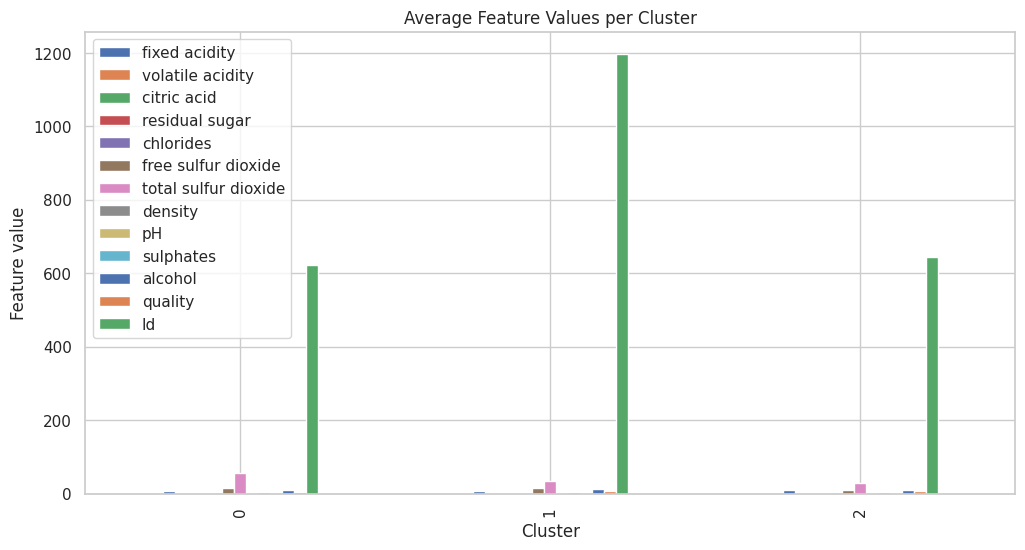

In [ ]:
cluster_summary.plot(kind='bar', figsize=(12,6))
plt.title("Average Feature Values per Cluster")
plt.ylabel("Feature value")
plt.show()


## PCA Visualization
PCA reduces the feature space to two dimensions. This helps visualize cluster separation even though the real data has many more dimensions.

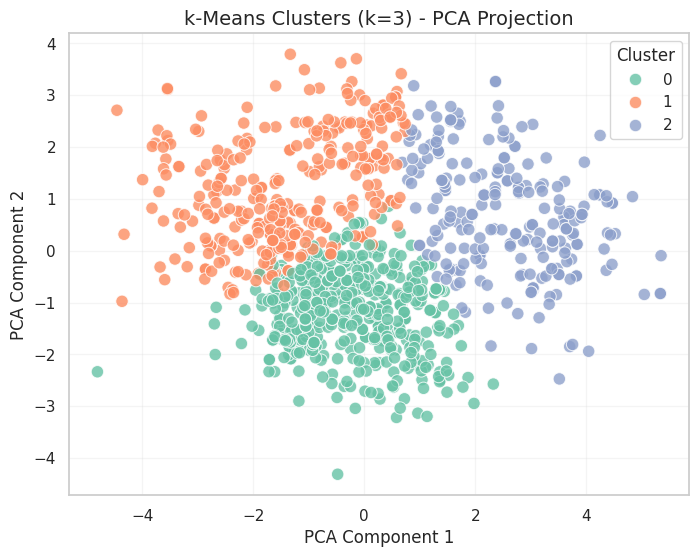

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0], y=X_pca[:,1],
    hue=data['Cluster'], palette='Set2',
    s=80, alpha=0.8
)
plt.title(f'k-Means Clusters (k={k_optimal}) - PCA Projection', fontsize=14)
plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.legend(title='Cluster')
plt.grid(alpha=0.2)
plt.show()


##Interpretation of the PCA Cluster Plot

The PCA projection gives a two-dimensional view of the clusters created by k-means. The clusters show some separation, although there is still overlap where the feature space compresses into two components. A few clusters appear closer together, which suggests that some wines share similar characteristics even after scaling. Other clusters are more spread out, indicating stronger differences in their feature profiles. The overall separation supports the choice of the selected k value, because the groups are reasonably distinct without showing excessive fragmentation.

# Cluster Summary
This table reports the average values of each feature for each cluster. It helps interpret the characteristics of the groups.

In [ ]:
# Average feature values per cluster
cluster_summary = data.groupby('Cluster').mean()
print("Cluster summary:\n", cluster_summary)

# compare with original wine quality
quality_summary = data.groupby('Cluster')['quality'].mean()
print("\nAverage wine quality per cluster:\n", quality_summary)


Cluster summary:
          fixed acidity  volatile acidity  citric acid  residual sugar  \
Cluster                                                                 
0             7.921639          0.607342     0.186912        2.348634   
1             7.240351          0.505702     0.201170        2.181725   
2            10.621930          0.401513     0.502061        2.809430   

         chlorides  free sulfur dioxide  total sulfur dioxide   density  \
Cluster                                                                   
0         0.085200            16.292017             55.560924  0.997120   
1         0.070576            15.757310             34.640351  0.995086   
2         0.089715            10.640351             30.197368  0.998250   

               pH  sulphates    alcohol   quality           Id  
Cluster                                                         
0        3.324706   0.592290   9.726015  5.292017   621.554622  
1        3.392427   0.656053  11.237378  5.94

## Interpretation of Cluster-Level Averages

The table above shows the average feature values for each cluster. It highlights how the chemical properties differ across the groups. Some clusters have higher alcohol levels or acidity, while others show lower sulphates or residual sugar. These differences help explain why the clustering algorithm separated the samples into distinct groups.

The second table summarizes the average wine quality score for each cluster. This allows us to see whether certain chemical profiles are linked to higher or lower quality ratings. Clusters with higher alcohol and balanced acidity tend to show slightly higher average quality, while clusters with weaker chemical characteristics show lower scores. Although quality was not used during training, the differences suggest that the clustering captured meaningful patterns in the data.


## Final Conclusion

The k-means algorithm was applied to the Wine Quality dataset to explore natural groupings in the data. After testing multiple values of k using the Elbow Method and validating with silhouette scores, the chosen number of clusters produced a balanced and meaningful structure. PCA visualizations supported this choice by showing reasonably distinct group boundaries in two-dimensional space. The analysis highlights how chemical properties influence wine groupings, and it demonstrates the importance of preprocessing, parameter tuning and visual evaluation. Further work could include trying alternative clustering methods such as DBSCAN or hierarchical clustering to compare performance.
